# Image Processing Fundamentals Project
## Computer Vision Practice - Week 2, Day 5 (Friday)

**Objective:** Integrate all week 2 concepts into a complete image processing pipeline.

**Deliverables:**
- Complete Image Processing Pipeline Class
- Professional visualization dashboard
- Interactive parameter tuning
- Real-world application demonstrations

## 1. Libraries & Setup


In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Libraries loaded!")

✓ Libraries loaded!


## 2. Complete Image Processing Pipeline

**Goal:** Create a reusable, professional image processing pipeline that combines all Week 2 techniques.

**Features:**
1. Color space conversion
2. Noise filtering
3. Edge detection
4. Image enhancement
5. Morphological operations
6. Visualization dashboard

In [7]:
# --- Image Processing Pipeline Class ---

class ImageProcessingPipeline:
    """Complete image processing pipeline combining all Week 2 techniques."""
    
    def __init__(self, image):
        """
        Initialize with an image.
        
        Parameters:
            image: Input image (BGR format)
        """
        self.original = image.copy()
        self.current = image.copy()
        self.processing_history = []
        
    def convert_color_space(self, target_space='HSV'):
        """Convert to different color spaces."""
        conversions = {
            'HSV': cv2.COLOR_BGR2HSV,
            'RGB': cv2.COLOR_BGR2RGB,
            'GRAY': cv2.COLOR_BGR2GRAY,
            'LAB': cv2.COLOR_BGR2LAB,
            'YUV': cv2.COLOR_BGR2YUV
        }
        
        if target_space in conversions:
            result = cv2.cvtColor(self.original, conversions[target_space])
            self.processing_history.append(f"Color conversion: {target_space}")
            return result
        return self.original
    
    def denoise(self, method='bilateral', strength=9):
        """Remove noise from image."""
        gray = cv2.cvtColor(self.original, cv2.COLOR_BGR2GRAY)
        
        if method == 'bilateral':
            result = cv2.bilateralFilter(gray, strength, 75, 75)
        elif method == 'gaussian':
            result = cv2.GaussianBlur(gray, (strength, strength), 0)
        elif method == 'median':
            result = cv2.medianBlur(gray, strength)
        else:
            result = cv2.blur(gray, (strength, strength))
            
        self.processing_history.append(f"Denoise: {method}")
        return result
    
    def detect_edges(self, method='canny', threshold1=50, threshold2=150):
        """Detect edges using different algorithms."""
        gray = cv2.cvtColor(self.original, cv2.COLOR_BGR2GRAY)
        
        if method == 'canny':
            result = cv2.Canny(gray, threshold1, threshold2)
        elif method == 'sobel':
            sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, 3)
            sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, 3)
            result = np.sqrt(sobel_x**2 + sobel_y**2).astype(np.uint8)
        elif method == 'laplacian':
            result = np.uint8(np.abs(cv2.Laplacian(gray, cv2.CV_64F)))
        else:
            result = cv2.Canny(gray, threshold1, threshold2)
            
        self.processing_history.append(f"Edge detection: {method}")
        return result
    
    def enhance_contrast(self, method='clahe'):
        """Enhance image contrast."""
        gray = cv2.cvtColor(self.original, cv2.COLOR_BGR2GRAY)
        
        if method == 'clahe':
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            result = clahe.apply(gray)
        elif method == 'histogram':
            result = cv2.equalizeHist(gray)
        else:
            result = gray
            
        self.processing_history.append(f"Contrast enhancement: {method}")
        return result
    
    def apply_morphology(self, image, operation='open', kernel_size=5):
        """Apply morphological operations."""
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        
        if operation == 'open':
            result = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
        elif operation == 'close':
            result = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
        elif operation == 'erode':
            result = cv2.erode(image, kernel, iterations=1)
        elif operation == 'dilate':
            result = cv2.dilate(image, kernel, iterations=1)
        else:
            result = image
            
        self.processing_history.append(f"Morphology: {operation}")
        return result
    
    def get_summary(self):
        """Get processing history."""
        return "\n".join([f"{i+1}. {step}" for i, step in enumerate(self.processing_history)])

print("✓ ImageProcessingPipeline class defined!")

✓ ImageProcessingPipeline class defined!


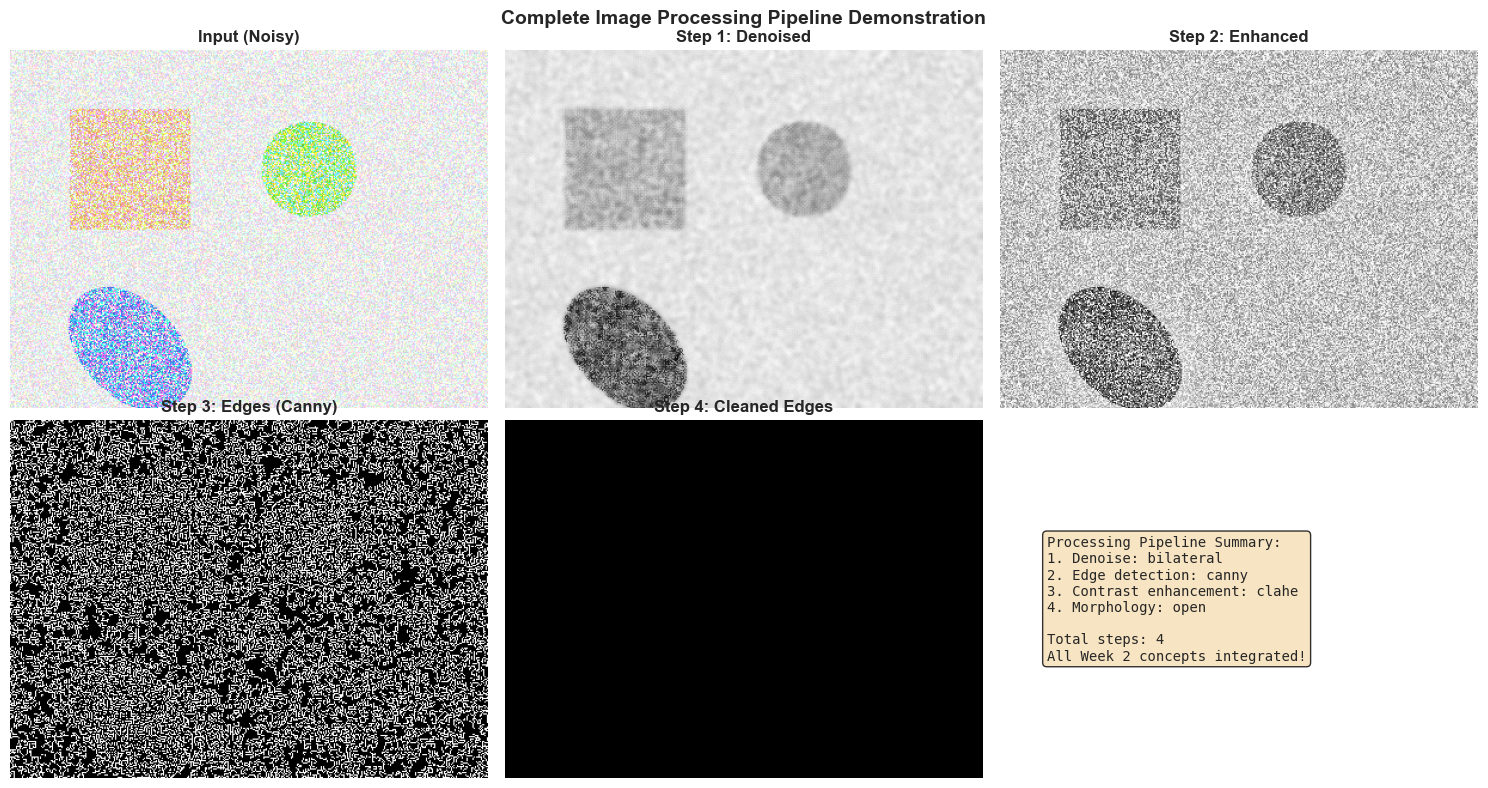

✓ Pipeline demonstration complete!

Processing Pipeline Summary:
1. Denoise: bilateral
2. Edge detection: canny
3. Contrast enhancement: clahe
4. Morphology: open

Total steps: 4
All Week 2 concepts integrated!


In [8]:
# --- Demonstration: Complete Pipeline on Sample Image ---

# Create a test image with multiple elements
demo_image = np.ones((300, 400, 3), dtype=np.uint8) * 200

# Add various shapes
cv2.rectangle(demo_image, (50, 50), (150, 150), (100, 150, 200), -1)
cv2.circle(demo_image, (250, 100), 40, (50, 200, 100), -1)
cv2.ellipse(demo_image, (100, 250), (60, 40), 45, 0, 360, (200, 100, 50), -1)

# Add noise
noise = np.random.normal(0, 20, demo_image.shape).astype(np.uint8)
noisy_demo = cv2.add(demo_image, noise)

# Initialize pipeline
pipeline = ImageProcessingPipeline(noisy_demo)

# Apply processing steps
step1 = pipeline.denoise(method='bilateral', strength=7)
step2 = pipeline.detect_edges(method='canny', threshold1=50, threshold2=150)
step3 = pipeline.enhance_contrast(method='clahe')
step4 = pipeline.apply_morphology(step2, operation='open', kernel_size=5)

# Visualize all steps
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(cv2.cvtColor(noisy_demo, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Input (Noisy)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(step1, cmap='gray')
axes[0, 1].set_title('Step 1: Denoised', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(step3, cmap='gray')
axes[0, 2].set_title('Step 2: Enhanced', fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(step2, cmap='gray')
axes[1, 0].set_title('Step 3: Edges (Canny)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(step4, cmap='gray')
axes[1, 1].set_title('Step 4: Cleaned Edges', fontweight='bold')
axes[1, 1].axis('off')

# Processing summary
summary_text = f"""Processing Pipeline Summary:
{pipeline.get_summary()}

Total steps: {len(pipeline.processing_history)}
All Week 2 concepts integrated!"""

axes[1, 2].text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
                verticalalignment='center', transform=axes[1, 2].transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[1, 2].axis('off')

plt.suptitle('Complete Image Processing Pipeline Demonstration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Pipeline demonstration complete!")
print(f"\n{summary_text}")

## 3. Real-World Application: Shape Detection & Analysis

**Use Case:** Detect and analyze shapes in an image
- Create binary image
- Find contours
- Calculate properties (area, perimeter, shape)
- Visualize results

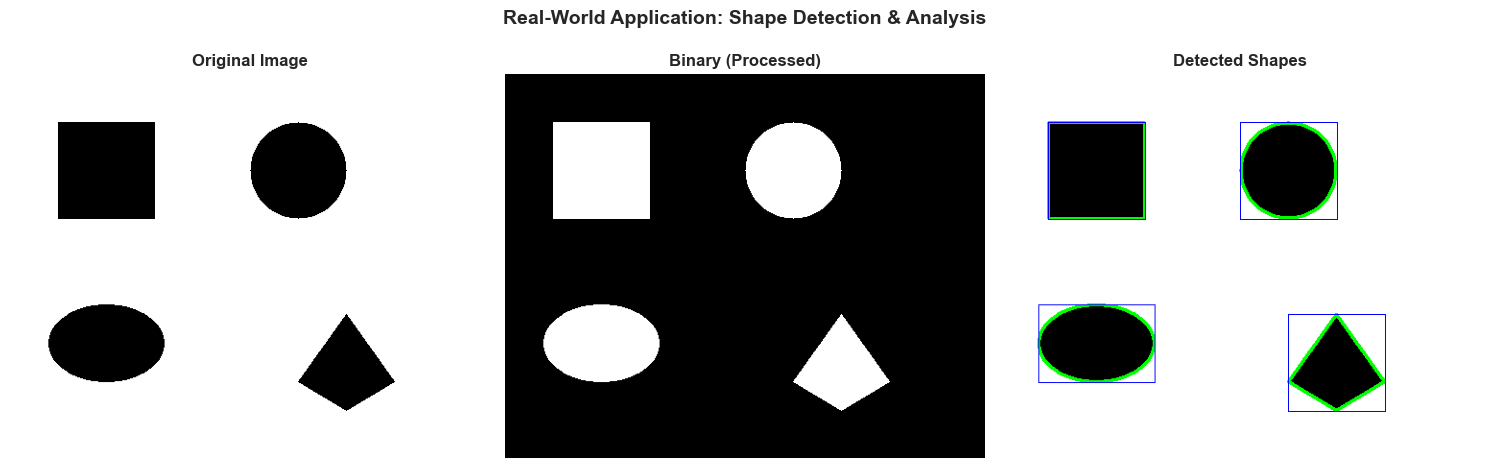

✓ Shape detection complete!

Detected Shapes:
----------------------------------------------------------------------
Shape 1: Square
  Area: 5000 pixels
  Perimeter: 306 pixels
  Circularity: 0.67

Shape 2: Circle
  Area: 7544 pixels
  Perimeter: 334 pixels
  Circularity: 0.85

Shape 3: Circle
  Area: 7704 pixels
  Perimeter: 329 pixels
  Circularity: 0.89

Shape 4: Square
  Area: 10000 pixels
  Perimeter: 400 pixels
  Circularity: 0.79



In [9]:
# --- Real-World Application: Shape Detection ---

# Create image with shapes
app_image = np.ones((400, 500, 3), dtype=np.uint8) * 255

# Draw various shapes
cv2.rectangle(app_image, (50, 50), (150, 150), (0, 0, 0), -1)        # Square
cv2.circle(app_image, (300, 100), 50, (0, 0, 0), -1)                  # Circle
cv2.ellipse(app_image, (100, 280), (60, 40), 0, 0, 360, (0, 0, 0), -1)  # Ellipse
points = np.array([[350, 250], [400, 320], [350, 350], [300, 320]], np.int32)
cv2.fillPoly(app_image, [points], (0, 0, 0))                          # Diamond

# Apply pipeline
gray = cv2.cvtColor(app_image, cv2.COLOR_BGR2GRAY)
binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY_INV)[1]
denoised = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))

# Find contours
contours, _ = cv2.findContours(denoised, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Analyze shapes
result = app_image.copy()
shape_data = []

for contour in contours:
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    
    if area > 100:  # Filter small contours
        # Draw contour
        cv2.drawContours(result, [contour], 0, (0, 255, 0), 2)
        
        # Get bounding box
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(result, (x, y), (x+w, y+h), (255, 0, 0), 1)
        
        # Circularity
        circularity = 4 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0
        
        # Determine shape
        if circularity > 0.8:
            shape = "Circle"
        elif w == h:
            shape = "Square"
        elif abs(w - h) < 20:
            shape = "Square"
        else:
            shape = "Rectangle"
        
        shape_data.append({
            'Shape': shape,
            'Area': int(area),
            'Perimeter': int(perimeter),
            'Circularity': f"{circularity:.2f}",
            'Position': (x, y)
        })

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(app_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(denoised, cmap='gray')
axes[1].set_title('Binary (Processed)', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[2].set_title('Detected Shapes', fontweight='bold')
axes[2].axis('off')

plt.suptitle('Real-World Application: Shape Detection & Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print results
print("✓ Shape detection complete!\n")
print("Detected Shapes:")
print("-" * 70)
for i, data in enumerate(shape_data, 1):
    print(f"Shape {i}: {data['Shape']}")
    print(f"  Area: {data['Area']} pixels")
    print(f"  Perimeter: {data['Perimeter']} pixels")
    print(f"  Circularity: {data['Circularity']}")
    print()

## 4. Summary & Key Takeaways

**Week 2 Concepts Covered:**

✅ **Day 1: Color Spaces**
- RGB, BGR, HSV, LAB conversions
- Channel splitting & merging
- Color range detection

✅ **Day 2: Filtering & Convolution**
- Convolution fundamentals
- Box, Gaussian, Median, Bilateral filters
- Custom kernel application

✅ **Day 3: Edge Detection & Morphology**
- Sobel, Canny, Laplacian edge detection
- Erosion, Dilation, Opening, Closing
- Morphological gradient

✅ **Day 4: Image Enhancement**
- Histogram equalization & CLAHE
- Brightness & contrast adjustment
- Gamma correction

✅ **Day 5: Project**
- Complete pipeline class
- Real-world application (shape detection)
- Professional visualization

**Next Steps:**
- Apply these techniques to your own images
- Experiment with parameter tuning
- Combine techniques for complex tasks
- Move to Week 3: Geometric Transforms & Contours